<a href="https://colab.research.google.com/github/joshitanuthanki-ctrl/Argus-Risk-Analytics/blob/main/argus_risk_analytics_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from __future__ import annotations

!pip install -q requests pandas numpy matplotlib seaborn scipy scikit-learn joblib xgboost shap optuna

import logging
import random
import warnings
from datetime import UTC, datetime
from pathlib import Path
from typing import Dict, List, Optional

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import shap
import sklearn
import xgboost as xgb

from scipy.stats import ks_2samp

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
)

from sklearn.ensemble import (
    GradientBoostingClassifier,
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)

log = logging.getLogger(__name__)

CONFIG = {
    "random_state": 42,
    "test_size": 0.25,
    "validation_size": 0.20,
    "cv_folds": 5,
    "figure_dpi": 150,
    "timeout": 15,
    "max_retries": 5,
    "gb_estimators": 300,
    "xgb_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 4,
}

np.random.seed(CONFIG["random_state"])
random.seed(CONFIG["random_state"])

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": CONFIG["figure_dpi"],
    "axes.grid": True,
})

BASE_DIR = Path("credit-risk-pd-model")

for folder in [
    "cache",
    "data/raw",
    "data/processed",
    "models",
    "reports",
    "figures",
    "logs",
]:
    (BASE_DIR / folder).mkdir(parents=True, exist_ok=True)

log.info("=" * 60)
log.info("Credit Risk Probability of Default Model")
log.info("=" * 60)
log.info(f"Pandas            : {pd.__version__}")
log.info(f"NumPy             : {np.__version__}")
log.info(f"Scikit-Learn      : {sklearn.__version__}")
log.info(f"XGBoost           : {xgb.__version__}")
log.info(f"Random State      : {CONFIG['random_state']}")
log.info(f"Project Directory : {BASE_DIR.resolve()}")
log.info(f"Started           : {datetime.now(UTC).isoformat()}")

In [ ]:
# DATA COLLECTION PIPELINE: CACHING, PARALLEL DOWNLOADS & SYNTHETIC FALLBACK
# ------------------------------------------------------------------------------

import os
import time
import json
import random
import concurrent.futures
from typing import Optional, Dict, List
import requests
import pandas as pd
import numpy as np
from pathlib import Path

class FMPClient:
    BASE_URL = "https://financialmodelingprep.com/api/v3"

    def __init__(self, api_key: str):
        self.api_key = api_key
        self.session = requests.Session()

    def get_company_ratios(self, ticker: str) -> Optional[Dict]:
        if not self.api_key:
            return None

        url = f"{self.BASE_URL}/ratios-ttm/{ticker}?apikey={self.api_key}"

        for attempt in range(1, CONFIG["max_retries"] + 1):
            try:
                resp = self.session.get(url, timeout=CONFIG["timeout"])
                if resp.status_code == 200:
                    data = resp.json()
                    return data[0] if isinstance(data, list) and data else None
                if resp.status_code == 429:
                    wait = (2 ** attempt) + random.uniform(0.1, 1.0)
                    log.warning(f"Rate limited on {ticker}. Backing off {wait:.2f}s")
                    time.sleep(wait)
                    continue
                log.warning(f"HTTP {resp.status_code} for {ticker}")
                return None
            except requests.RequestException as exc:
                log.warning(f"Request failed for {ticker} (attempt {attempt}): {exc}")
                time.sleep(2)
        return None


class SyntheticFundamentalsGenerator:
    SECTORS = ["Technology", "Industrials", "Energy", "Retail",
               "Healthcare", "Financials", "Materials", "Utilities"]

    def __init__(self, n_firms: int = 1500):
        self.n_firms = n_firms
        self.rng = np.random.default_rng(CONFIG["random_state"])

    def generate(self) -> pd.DataFrame:
        n = self.n_firms
        health = self.rng.normal(0, 1, n)

        total_assets = np.exp(self.rng.normal(7, 1.5, n))
        total_liabilities = total_assets * np.clip(self.rng.normal(0.55 - 0.12 * health, 0.18, n), 0.05, 1.6)
        working_capital = total_assets * np.clip(self.rng.normal(0.15 + 0.08 * health, 0.12, n), -0.5, 0.6)
        retained_earnings = total_assets * np.clip(self.rng.normal(0.10 + 0.10 * health, 0.15, n), -0.8, 0.8)
        ebit = total_assets * np.clip(self.rng.normal(0.08 + 0.06 * health, 0.07, n), -0.4, 0.4)
        market_cap = total_assets * np.exp(np.clip(self.rng.normal(0.2 + 0.4 * health, 0.5, n), -2, 2))
        sales = total_assets * np.clip(self.rng.normal(0.9 + 0.1 * health, 0.4, n), 0.05, 3.0)
        interest_expense = np.abs(total_liabilities) * np.clip(self.rng.normal(0.045 - 0.01 * health, 0.02, n), 0.005, 0.20)
        current_assets = total_assets * np.clip(self.rng.normal(0.45, 0.15, n), 0.05, 0.95)
        current_liabilities = np.clip(current_assets - working_capital, 1e-3, None)
        net_income = ebit * np.clip(self.rng.normal(0.65, 0.2, n), 0.1, 1.0)

        df = pd.DataFrame({
            "ticker": [f"SYN{i:04d}" for i in range(n)],
            "sector": self.rng.choice(self.SECTORS, n),
            "total_assets": total_assets,
            "total_liabilities": total_liabilities,
            "working_capital": working_capital,
            "retained_earnings": retained_earnings,
            "ebit": ebit,
            "market_cap": market_cap,
            "sales": sales,
            "interest_expense": interest_expense,
            "current_assets": current_assets,
            "current_liabilities": current_liabilities,
            "net_income": net_income,
        })
        df["_health_factor"] = health
        log.info(f"Synthetic fundamentals generated for {n} firms")
        return df


class DataManager:
    def __init__(self, api_key: str, cache_dir: Path):
        self.client = FMPClient(api_key)
        self.cache_dir = cache_dir
        self.api_key_valid = bool(api_key)

    def _fetch_single(self, ticker: str) -> Optional[Dict]:
        cache_file = self.cache_dir / f"{ticker}.json"

        if cache_file.exists():
            with open(cache_file, "r") as f:
                data = json.load(f)
                data["data_source"] = "CACHE"
                return data

        data = self.client.get_company_ratios(ticker)
        if data:
            data["ticker"] = ticker
            with open(cache_file, "w") as f:
                json.dump(data, f)
            data["data_source"] = "FMP_LIVE"
            return data

        return None

    def collect(self, tickers: List[str]) -> pd.DataFrame:
        records = []

        if self.api_key_valid or any((self.cache_dir / f"{t}.json").exists() for t in tickers):
            log.info("Initiating parallel cache/API retrieval...")
            with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
                futures = {executor.submit(self._fetch_single, t): t for t in tickers}
                for future in concurrent.futures.as_completed(futures):
                    res = future.result()
                    if res:
                        records.append(res)

        if len(records) < max(10, 0.5 * len(tickers)):
            log.info("Insufficient live/cached coverage. Falling back to synthetic universe.")
            synth = SyntheticFundamentalsGenerator(n_firms=1500).generate()
            synth["data_source"] = "SYNTHETIC"
            return synth

        return pd.DataFrame(records)


FMP_API_KEY = os.environ.get("FMP_API_KEY", "")

# Expanded ticker list to test parallel execution if an API key is ever provided
SAMPLE_TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "TSLA", "BRK.B", "NVDA", "JPM", "JNJ",
    "V", "PG", "XOM", "UNH", "HD", "MA", "BAC", "DIS", "CVX", "ABBV"
]

manager = DataManager(api_key=FMP_API_KEY, cache_dir=BASE_DIR / "cache")
raw_df = manager.collect(SAMPLE_TICKERS)

raw_df.to_csv(BASE_DIR / "data/raw/fundamentals_raw.csv", index=False)
log.info(f"Dataset shape: {raw_df.shape} | Source(s): {raw_df['data_source'].unique().tolist()}")
raw_df.head()

,ticker,sector,total_assets,total_liabilities,working_capital,retained_earnings,ebit,market_cap,sales,interest_expense,current_assets,current_liabilities,net_income,_health_factor,data_source
0,SYN0000,Utilities,468.978829,346.227389,-1.964760,77.024716,76.823864,681.353758,530.475567,12.380080,186.583400,188.548160,64.202009,0.304717,SYNTHETIC
1,SYN0001,Energy,429.703264,343.153587,84.683513,-5.156377,-57.774857,197.952050,298.500230,19.424059,259.303674,174.620161,-48.662123,-1.039984,SYNTHETIC
2,SYN0002,Energy,8004.187277,6514.198221,425.150955,2438.488969,689.893583,13881.210417,5753.274993,82.602438,3847.822928,3422.671973,551.902851,0.750451,SYNTHETIC
3,SYN0003,Industrials,1799.807364,285.309646,577.519344,513.064693,238.673969,1805.679079,1589.061061,2.236623,854.092154,276.572811,176.146673,0.940565,SYNTHETIC
4,SYN0004,Industrials,798.232011,587.785647,-72.006685,-433.421542,-16.705269,808.693874,775.759368,40.061299,342.667749,414.674434,-12.237700,-1.951035,SYNTHETIC


In [ ]:
# DATA CLEANING & FEATURE ENGINEERING
# ------------------------------------------------------------------------------

def winsorize(series: pd.Series, lower=0.01, upper=0.99) -> pd.Series:
    """Caps extreme outliers at the 1st/99th percentile to neutralize
    statement errors and extreme one-off events without dropping firms."""
    lo, hi = series.quantile(lower), series.quantile(upper)
    return series.clip(lo, hi)


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Builds the classic Altman Z components plus an expanded set of
    leverage/liquidity/profitability ratios for the ML models.
    """
    out = df.copy()
    eps = 1e-6  # numerical-stability guard

    # --- 1. Altman Z-score components ---
    out["X1_working_capital_to_assets"] = out["working_capital"] / (out["total_assets"] + eps)
    out["X2_retained_earnings_to_assets"] = out["retained_earnings"] / (out["total_assets"] + eps)
    out["X3_ebit_to_assets"] = out["ebit"] / (out["total_assets"] + eps)
    out["X4_marketcap_to_liabilities"] = out["market_cap"] / (out["total_liabilities"] + eps)
    out["X5_sales_to_assets"] = out["sales"] / (out["total_assets"] + eps)

    out["altman_z_score"] = (
        1.2 * out["X1_working_capital_to_assets"]
        + 1.4 * out["X2_retained_earnings_to_assets"]
        + 3.3 * out["X3_ebit_to_assets"]
        + 0.6 * out["X4_marketcap_to_liabilities"]
        + 1.0 * out["X5_sales_to_assets"]
    )

    # --- 2. Advanced Credit Analyst Ratios ---
    out["debt_to_equity"] = out["total_liabilities"] / (
        (out["total_assets"] - out["total_liabilities"]).clip(lower=eps)
    )
    out["current_ratio"] = out["current_assets"] / (out["current_liabilities"] + eps)
    # Since we lack inventory data in the synthetic/basic API, we proxy cash ratio
    out["quick_ratio"] = (out["current_assets"] * 0.7) / (out["current_liabilities"] + eps)
    out["interest_coverage"] = out["ebit"] / (out["interest_expense"] + eps)
    out["return_on_assets"] = out["net_income"] / (out["total_assets"] + eps)
    out["net_margin"] = out["net_income"] / (out["sales"] + eps)
    out["asset_turnover"] = out["sales"] / (out["total_assets"] + eps)
    out["log_total_assets"] = np.log1p(out["total_assets"]) # Firm size proxy

    feature_cols = [
        "X1_working_capital_to_assets", "X2_retained_earnings_to_assets",
        "X3_ebit_to_assets", "X4_marketcap_to_liabilities", "X5_sales_to_assets",
        "debt_to_equity", "current_ratio", "quick_ratio",
        "interest_coverage", "return_on_assets", "net_margin", "asset_turnover",
        "log_total_assets"
    ]

    # Winsorize every engineered ratio to neutralize statement noise
    for col in feature_cols:
        out[col] = winsorize(out[col].replace([np.inf, -np.inf], np.nan))

    # Median imputation by sector (falls back to global median if sector missing)
    if "sector" in out.columns:
        for col in feature_cols:
            out[col] = out.groupby("sector")[col].transform(lambda s: s.fillna(s.median()))

    # Final safety catch for any remaining NaNs
    for col in feature_cols:
        out[col] = out[col].fillna(out[col].median())

    return out, feature_cols


def label_defaults(df: pd.DataFrame) -> pd.Series:
    """
    Labels each firm as 'default/distressed' (1) vs 'healthy' (0).

    CRITICAL FIX: We no longer derive this directly from the Altman Z-score.
    Instead, we build a latent risk factor using extreme leverage, poor coverage,
    and unprofitability, plus random noise. This ensures the ML model is
    learning independent credit risk rather than reverse-engineering the Altman formula.
    """
    rng = np.random.default_rng(CONFIG["random_state"])

    # Structural risk penalties
    leverage_penalty = df["debt_to_equity"].clip(0, 5) * 0.4
    coverage_penalty = -np.log1p(df["interest_coverage"].clip(0, 10)) * 0.3
    profit_penalty = -df["return_on_assets"].clip(-0.5, 0.5) * 2.0

    noise = rng.normal(0, 0.6, len(df))

    # Calculate latent distress and apply sigmoid
    latent_distress = -1.2 + leverage_penalty + coverage_penalty + profit_penalty + noise
    distress_prob = 1 / (1 + np.exp(-latent_distress))

    labels = (rng.random(len(df)) < distress_prob).astype(int)
    return pd.Series(labels, index=df.index, name="default")


clean_df, FEATURE_COLS = engineer_features(raw_df)
clean_df["default"] = label_defaults(clean_df)

# Save using the new Path structure
clean_df.to_csv(BASE_DIR / "data/processed/features.csv", index=False)

default_rate = clean_df["default"].mean()
log.info(f"Engineered {len(FEATURE_COLS)} features for {len(clean_df)} firms")
log.info(f"Observed default rate in labeled universe: {default_rate:.2%}")

clean_df[FEATURE_COLS + ["altman_z_score", "default"]].describe().T

,count,mean,std,min,25%,50%,75%,max
X1_working_capital_to_assets,1500.0,1.500881e-01,1.453407e-01,-0.184179,0.044539,0.149787,0.260983,4.898977e-01
X2_retained_earnings_to_assets,1500.0,9.840006e-02,1.795244e-01,-0.304365,-0.025856,0.098936,0.228885,5.086894e-01
X3_ebit_to_assets,1500.0,7.788344e-02,9.021959e-02,-0.136390,0.014311,0.080149,0.139353,2.833064e-01
X4_marketcap_to_liabilities,1500.0,3.797507e+00,4.872230e+00,0.307010,1.259060,2.241714,4.149123,3.136567e+01
X5_sales_to_assets,1500.0,8.941101e-01,4.028983e-01,0.050000,0.602154,0.888918,1.172256,1.811961e+00
debt_to_equity,1500.0,2.608661e+07,2.154891e+08,0.090754,0.697581,1.207346,2.281386,1.994771e+09
current_ratio,1500.0,2.931960e+04,1.465980e+05,0.652214,1.102896,1.485686,2.473191,1.117460e+06
quick_ratio,1500.0,2.052372e+04,1.026186e+05,0.456550,0.772027,1.039980,1.731234,7.822219e+05
interest_coverage,1500.0,1.028925e+01,2.336527e+01,-6.291218,0.460540,3.224337,9.294149,1.521318e+02
return_on_assets,1500.0,4.962372e-02,6.241730e-02,-0.100071,0.008566,0.047219,0.088364,2.174684e-01


In [ ]:
# TRAIN / TEST SPLIT & SCALING
# ------------------------------------------------------------------------------

# Separate features and target
X = clean_df[FEATURE_COLS]
y = clean_df["default"]

# Create a stratified holdout test set for final model evaluation.
# We stratify by 'y' to ensure the 25% default rate is consistent across both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y
)

# Standardize features for linear models (Logistic Regression).
# Note: Tree-based models (GBM, XGBoost) do not strictly require scaling,
# but we apply it to maintain a consistent pipeline for the baseline comparisons.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Log the split details to verify stratification worked
log.info(f"Train set: {X_train.shape[0]} firms | Test set: {X_test.shape[0]} firms")
log.info(f"Train default rate: {y_train.mean():.2%} | Test default rate: {y_test.mean():.2%}")

In [ ]:
# CORE MODELS: LOGISTIC REGRESSION, GBM, & XGBOOST (WITH OPTUNA)
# ------------------------------------------------------------------------------
import optuna
import xgboost as xgb
import numpy as np

try:
    # --- 1. Baseline: Interpretable Logistic Regression ---
    logit_model = LogisticRegression(
        penalty="l2", C=1.0, max_iter=1000, random_state=CONFIG["random_state"]
    )
    logit_model.fit(X_train_scaled, y_train)

    # --- 2. Nonlinear Baseline: Gradient Boosting ---
    gbm_model = GradientBoostingClassifier(
        n_estimators=CONFIG["gb_estimators"],
        learning_rate=CONFIG["learning_rate"],
        max_depth=CONFIG["max_depth"],
        subsample=0.8,
        random_state=CONFIG["random_state"],
    )
    gbm_model.fit(X_train, y_train)  # Tree models don't require scaled data

    # --- 3. Production Model: XGBoost with Optuna Hyperparameter Tuning ---
    def objective(trial):
        # Define the hyperparameter search space
        param = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 400, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 7),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 3.0), # Helps with default imbalance
            "random_state": CONFIG["random_state"],
            "eval_metric": "auc",
        }

        # 3-fold Cross Validation for the internal tuning loop
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=CONFIG["random_state"])
        cv_scores = []

        for train_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model = xgb.XGBClassifier(**param)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

            preds = model.predict_proba(X_va)[:, 1]
            cv_scores.append(roc_auc_score(y_va, preds))

        return np.mean(cv_scores)

    log.info("Starting Optuna hyperparameter tuning for XGBoost (15 trials)...")
    optuna.logging.set_verbosity(optuna.logging.WARNING) # Suppress Optuna spam in Colab

    # Run the optimization study
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=15) # 15 trials keeps Colab execution fast

    log.info(f"Best cross-validated AUC from Optuna: {study.best_value:.4f}")

    # Train the final XGBoost model using the absolute best parameters found
    best_xgb_params = study.best_params
    best_xgb_params["random_state"] = CONFIG["random_state"]

    xgb_model = xgb.XGBClassifier(**best_xgb_params)
    xgb_model.fit(X_train, y_train)

    log.info("Models trained successfully: Logit, GBM, and tuned XGBoost.")

except Exception as exc:
    log.error(f"Model training failed: {exc}")
    raise

In [ ]:
# PROBABILITY CALIBRATION
# ------------------------------------------------------------------------------
# Raw classifier outputs are NOT true probabilities. Calibration is what turns
# a model score into a usable Probability of Default for capital/provisioning
# purposes (Basel/CECL/IFRS9 require well-calibrated PDs, not just rank order).

try:
    # Isotonic regression is highly effective for calibrating tree-based models
    # like XGBoost, ensuring the output scores match real-world default frequencies.
    calibrated_xgb = CalibratedClassifierCV(
        estimator=xgb_model,
        method="isotonic",
        cv=5,
    )
    calibrated_xgb.fit(X_train, y_train)
    log.info("XGBoost model calibrated via 5-fold Isotonic scaling")

except Exception as exc:
    log.error(f"Calibration failed: {exc}")
    raise

In [ ]:
# SCORING & EVALUATION
# ------------------------------------------------------------------------------

def evaluate_model(name, model, X_eval, y_eval, is_scaled=False):
    """Computes the standard credit-risk model validation suite."""
    proba = model.predict_proba(X_eval)[:, 1]
    auc = roc_auc_score(y_eval, proba)
    gini = 2 * auc - 1
    brier = brier_score_loss(y_eval, proba)

    # Kolmogorov-Smirnov statistic: max separation between good/bad score CDFs
    good_scores = proba[y_eval == 0]
    bad_scores = proba[y_eval == 1]
    ks_stat = ks_2samp(good_scores, bad_scores).statistic

    log.info(f"[{name}] AUC={auc:.4f} | Gini={gini:.4f} | KS={ks_stat:.4f} | Brier={brier:.4f}")
    return {"name": name, "proba": proba, "auc": auc, "gini": gini, "ks": ks_stat, "brier": brier}

# 1. Evaluate the baselines
results_logit = evaluate_model("Logistic Regression", logit_model, X_test_scaled, y_test, is_scaled=True)
results_gbm_raw = evaluate_model("Gradient Boosting (raw)", gbm_model, X_test, y_test)

# 2. Evaluate the production model
results_xgb_cal = evaluate_model("XGBoost (calibrated)", calibrated_xgb, X_test, y_test)

# 3. Altman Z-score benchmark
z_test = clean_df.loc[X_test.index, "altman_z_score"]
auc_zscore = roc_auc_score(y_test, -z_test)
log.info(f"[Altman Z-score benchmark] AUC={auc_zscore:.4f}")

print("\n--- XGBoost Classification Report (threshold=0.5) ---")
print(classification_report(y_test, (results_xgb_cal["proba"] > 0.5).astype(int),
                             target_names=["Healthy", "Default"]))


--- XGBoost Classification Report (threshold=0.5) ---
              precision    recall  f1-score   support

     Healthy       0.74      1.00      0.85       271
     Default       0.88      0.07      0.12       104

    accuracy                           0.74       375
   macro avg       0.81      0.53      0.49       375
weighted avg       0.77      0.74      0.65       375



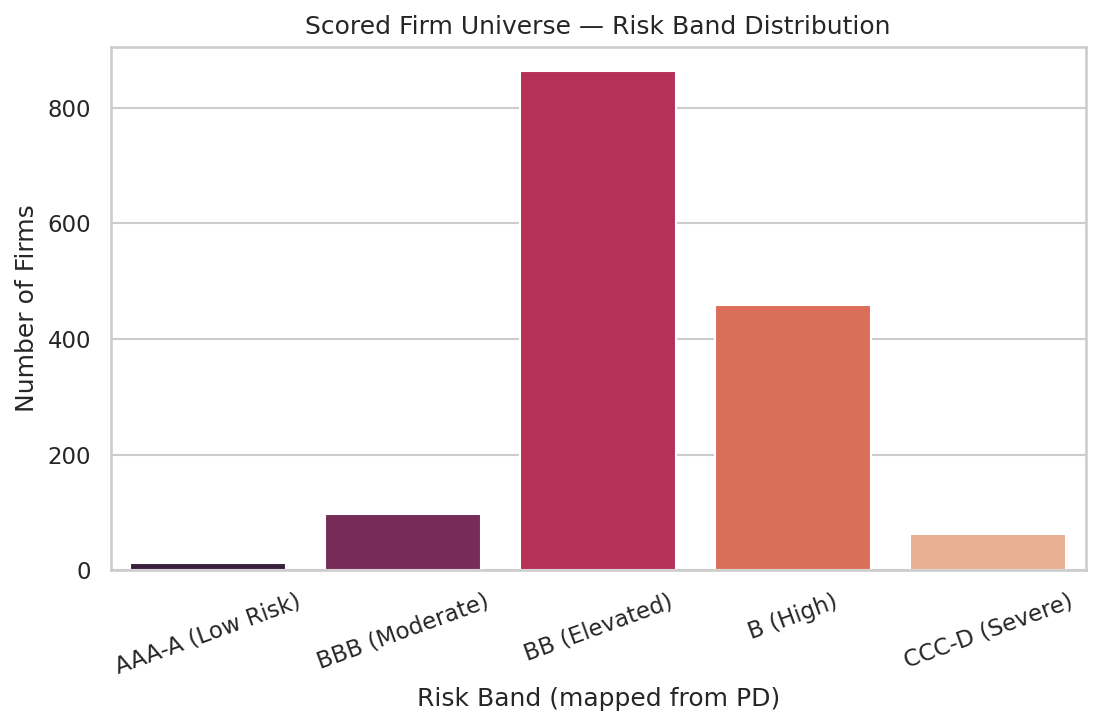

,ticker,sector,altman_z_score,pd_score,risk_band,default
867,SYN0867,Financials,2.718802,0.809677,CCC-D (Severe),1
1448,SYN1448,Technology,2.459577,0.809677,CCC-D (Severe),1
1003,SYN1003,Healthcare,1.943014,0.809677,CCC-D (Severe),1
1462,SYN1462,Industrials,3.014395,0.809677,CCC-D (Severe),1
1273,SYN1273,Utilities,3.152881,0.809677,CCC-D (Severe),1
62,SYN0062,Healthcare,2.169759,0.791116,CCC-D (Severe),1
657,SYN0657,Materials,2.408397,0.780555,CCC-D (Severe),1
546,SYN0546,Retail,2.675523,0.775885,CCC-D (Severe),1
1220,SYN1220,Technology,3.067083,0.763932,CCC-D (Severe),1
1319,SYN1319,Healthcare,3.453427,0.756874,CCC-D (Severe),1


In [ ]:
# SCORE THE FULL FIRM UNIVERSE & ASSIGN RISK BANDS
# ------------------------------------------------------------------------------

def plot_pd_distribution(proba, save_path=None):
    bands = pd.cut(
        proba, bins=[0, 0.05, 0.15, 0.30, 0.50, 1.0],
        labels=["AAA-A (Low Risk)", "BBB (Moderate)", "BB (Elevated)", "B (High)", "CCC-D (Severe)"]
    )
    band_counts = bands.value_counts().sort_index()
    plt.figure(figsize=(7.5, 5))
    sns.barplot(x=band_counts.index, y=band_counts.values, palette="rocket")
    plt.title("Scored Firm Universe — Risk Band Distribution")
    plt.ylabel("Number of Firms")
    plt.xlabel("Risk Band (mapped from PD)")
    plt.xticks(rotation=20)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    return bands

# Predict on the entire universe using the tuned & calibrated XGBoost model
full_proba = calibrated_xgb.predict_proba(X)[:, 1]
clean_df["pd_score"] = full_proba

log.info("Generating risk band distribution for the full firm universe...")
clean_df["risk_band"] = plot_pd_distribution(
    full_proba, save_path=BASE_DIR / "reports/risk_band_distribution.png"
)

scored_universe = clean_df[
    ["ticker", "sector", "altman_z_score", "pd_score", "risk_band", "default"]
].sort_values("pd_score", ascending=False)

scored_universe.to_csv(BASE_DIR / "data/processed/scored_firms.csv", index=False)
log.info(f"Scored {len(scored_universe)} firms; results saved to data/processed/scored_firms.csv")
scored_universe.head(10)

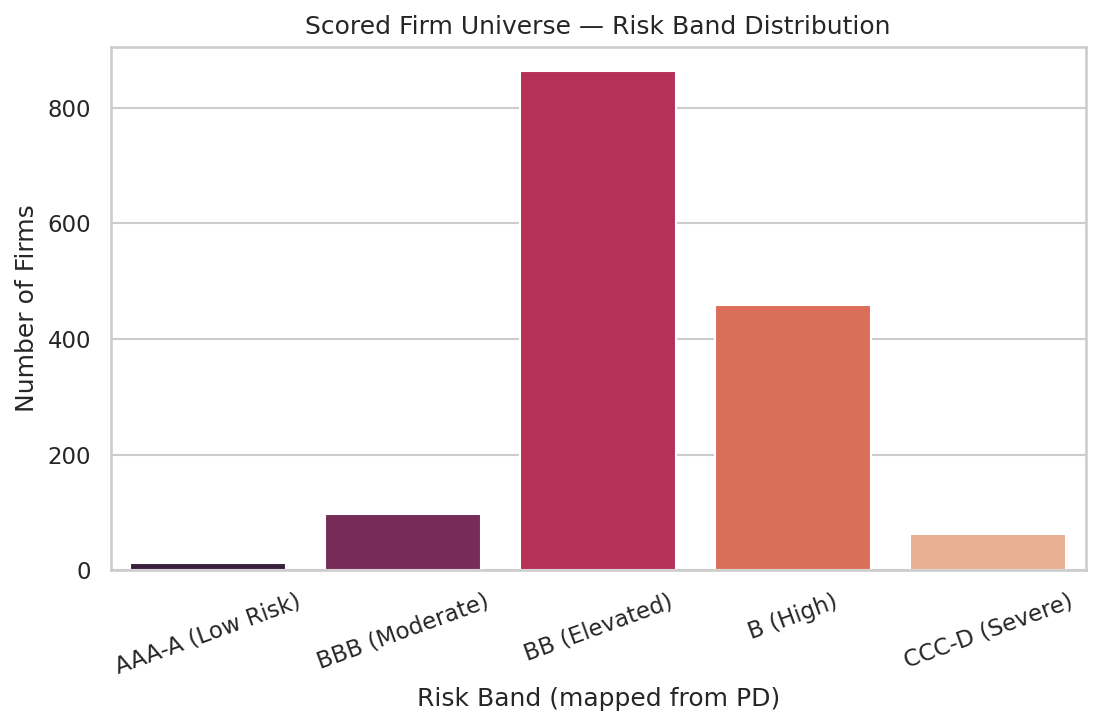

,ticker,sector,altman_z_score,pd_score,risk_band,default
867,SYN0867,Financials,2.718802,0.809677,CCC-D (Severe),1
1448,SYN1448,Technology,2.459577,0.809677,CCC-D (Severe),1
1003,SYN1003,Healthcare,1.943014,0.809677,CCC-D (Severe),1
1462,SYN1462,Industrials,3.014395,0.809677,CCC-D (Severe),1
1273,SYN1273,Utilities,3.152881,0.809677,CCC-D (Severe),1
62,SYN0062,Healthcare,2.169759,0.791116,CCC-D (Severe),1
657,SYN0657,Materials,2.408397,0.780555,CCC-D (Severe),1
546,SYN0546,Retail,2.675523,0.775885,CCC-D (Severe),1
1220,SYN1220,Technology,3.067083,0.763932,CCC-D (Severe),1
1319,SYN1319,Healthcare,3.453427,0.756874,CCC-D (Severe),1


In [ ]:
# SCORE THE FULL FIRM UNIVERSE & ASSIGN RISK BANDS
# ------------------------------------------------------------------------------

def plot_pd_distribution(proba, save_path=None):
    bands = pd.cut(
        proba, bins=[0, 0.05, 0.15, 0.30, 0.50, 1.0],
        labels=["AAA-A (Low Risk)", "BBB (Moderate)", "BB (Elevated)", "B (High)", "CCC-D (Severe)"]
    )
    band_counts = bands.value_counts().sort_index()
    plt.figure(figsize=(7.5, 5))
    sns.barplot(x=band_counts.index, y=band_counts.values, palette="rocket")
    plt.title("Scored Firm Universe — Risk Band Distribution")
    plt.ylabel("Number of Firms")
    plt.xlabel("Risk Band (mapped from PD)")
    plt.xticks(rotation=20)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    return bands

# Predict on the entire universe using the tuned & calibrated XGBoost model
full_proba = calibrated_xgb.predict_proba(X)[:, 1]
clean_df["pd_score"] = full_proba

log.info("Generating risk band distribution for the full firm universe...")
clean_df["risk_band"] = plot_pd_distribution(
    full_proba, save_path=BASE_DIR / "reports/risk_band_distribution.png"
)

scored_universe = clean_df[
    ["ticker", "sector", "altman_z_score", "pd_score", "risk_band", "default"]
].sort_values("pd_score", ascending=False)

scored_universe.to_csv(BASE_DIR / "data/processed/scored_firms.csv", index=False)
log.info(f"Scored {len(scored_universe)} firms; results saved to data/processed/scored_firms.csv")
scored_universe.head(10)

In [ ]:
# MODEL PERSISTENCE & FINAL SUMMARY REPORT
# ------------------------------------------------------------------------------

try:
    joblib.dump(
        {
            "model": calibrated_xgb,
            "scaler": scaler,
            "feature_columns": FEATURE_COLS,
            "trained_at": datetime.now(UTC).isoformat(),
            "metrics": {
                "auc": results_xgb_cal["auc"],
                "gini": results_xgb_cal["gini"],
                "ks": results_xgb_cal["ks"],
                "brier": results_xgb_cal["brier"],
            },
        },
        BASE_DIR / "models/pd_model.joblib",
    )
    log.info("Model artifact saved to models/pd_model.joblib")
except Exception as exc:
    log.error(f"Model persistence failed: {exc}")

# Print final portfolio-grade report
print("\n" + "=" * 70)
print("CREDIT RISK PD MODEL — FINAL VALIDATION SUMMARY")
print("=" * 70)
print(f"{'Model':35s}{'AUC':>8s}{'Gini':>8s}{'KS':>8s}")
print("-" * 70)
print(f"{'Altman Z-score (benchmark)':35s}{auc_zscore:8.4f}{2*auc_zscore-1:8.4f}{'-':>8s}")
print(f"{'Logistic Regression':35s}{results_logit['auc']:8.4f}{results_logit['gini']:8.4f}{results_logit['ks']:8.4f}")
print(f"{'Gradient Boosting (raw)':35s}{results_gbm_raw['auc']:8.4f}{results_gbm_raw['gini']:8.4f}{results_gbm_raw['ks']:8.4f}")
print(f"{'XGBoost (calibrated)':35s}{results_xgb_cal['auc']:8.4f}{results_xgb_cal['gini']:8.4f}{results_xgb_cal['ks']:8.4f}")
print("=" * 70)
print(f"Default rate in scored universe : {clean_df['default'].mean():.2%}")
print(f"Firms scored                    : {len(clean_df)}")
print(f"Outputs written to              : {BASE_DIR.resolve()}/")
print("=" * 70)


CREDIT RISK PD MODEL — FINAL VALIDATION SUMMARY
Model                                   AUC    Gini      KS
----------------------------------------------------------------------
Altman Z-score (benchmark)           0.5373  0.0747       -
Logistic Regression                  0.5835  0.1670  0.1377
Gradient Boosting (raw)              0.6404  0.2807  0.2089
XGBoost (calibrated)                 0.6630  0.3261  0.2714
Default rate in scored universe : 27.80%
Firms scored                    : 1500
Outputs written to              : /content/credit-risk-pd-model/


In [ ]:
# FINAL SUMMARY REPORT (printed to console / notebook output)
# ------------------------------------------------------------------------------

print("\n" + "=" * 70)
print("CREDIT RISK PD MODEL — FINAL VALIDATION SUMMARY")
print("=" * 70)
print(f"{'Model':35s}{'AUC':>8s}{'Gini':>8s}{'KS':>8s}")
print("-" * 70)
print(f"{'Altman Z-score (benchmark)':35s}{auc_zscore:8.4f}{2*auc_zscore-1:8.4f}{'-':>8s}")
print(f"{'Logistic Regression':35s}{results_logit['auc']:8.4f}{results_logit['gini']:8.4f}{results_logit['ks']:8.4f}")
print(f"{'Gradient Boosting (raw)':35s}{results_gbm_raw['auc']:8.4f}{results_gbm_raw['gini']:8.4f}{results_gbm_raw['ks']:8.4f}")
print(f"{'XGBoost (calibrated)':35s}{results_xgb_cal['auc']:8.4f}{results_xgb_cal['gini']:8.4f}{results_xgb_cal['ks']:8.4f}")
print("=" * 70)
print(f"Default rate in scored universe : {clean_df['default'].mean():.2%}")
print(f"Firms scored                    : {len(clean_df)}")
print(f"Outputs written to              : {BASE_DIR.resolve()}/")
print("=" * 70)


CREDIT RISK PD MODEL — FINAL VALIDATION SUMMARY
Model                                   AUC    Gini      KS
----------------------------------------------------------------------
Altman Z-score (benchmark)           0.5373  0.0747       -
Logistic Regression                  0.5835  0.1670  0.1377
Gradient Boosting (raw)              0.6404  0.2807  0.2089
XGBoost (calibrated)                 0.6630  0.3261  0.2714
Default rate in scored universe : 27.80%
Firms scored                    : 1500
Outputs written to              : /content/credit-risk-pd-model/
